# Grad-CAM

# Environment Prep

In [1]:
import os
import json
import platform
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import load_model

print("Libraries imported successfully.")

2026-06-26 07:08:59.304375: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782457739.840163      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782457739.954965      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782457741.180216      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782457741.180255      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782457741.180258      23 computation_placer.cc:177] computation placer alr

Libraries imported successfully.


In [2]:
def print_section(title):

    print("\n" + "=" * 70)
    print(title.upper())
    print("=" * 70)


def print_status(name, status):

    icon = "PASS" if status else "FAIL"

    print(f"{name:<35}: {icon}")

In [3]:
print_section("Environment Validation")

print(f"Python Version      : {platform.python_version()}")
print(f"TensorFlow Version  : {tf.__version__}")
print(f"NumPy Version       : {np.__version__}")
print(f"OpenCV Version      : {cv2.__version__}")

gpus = tf.config.list_physical_devices("GPU")

GPU_AVAILABLE = len(gpus) > 0

print()

if GPU_AVAILABLE:

    print(f"GPU Detected        : {len(gpus)}")

    for gpu in gpus:

        print(f" - {gpu.name}")

else:

    print("GPU Detected        : None")


ENVIRONMENT VALIDATION
Python Version      : 3.12.13
TensorFlow Version  : 2.19.0
NumPy Version       : 2.4.6
OpenCV Version      : 4.13.0

GPU Detected        : 2
 - /physical_device:GPU:0
 - /physical_device:GPU:1


In [4]:
#Project Dir
print_section("Project Structure")

NOTEBOOK1_ROOT = Path(
    "/kaggle/input/notebooks/hapizh/deeplearning1"
)

NOTEBOOK2_ROOT = Path(
    "/kaggle/input/notebooks/hapizh/deeplearning2"
)

WORKSPACE = Path(
    "/kaggle/working/explainability"
)

DATASET_PATH = NOTEBOOK1_ROOT / "classification_dataset"

EXPERIMENT_PATH = NOTEBOOK1_ROOT / "experiments"

PREDICTION_CSV = (
    NOTEBOOK2_ROOT
    / "evaluation"
    / "prediction_results.csv"
)

SUMMARY_JSON = (
    NOTEBOOK2_ROOT
    / "evaluation"
    / "evaluation_summary.json"
)

required_paths = {

    "Notebook 1" : NOTEBOOK1_ROOT,

    "Notebook 2" : NOTEBOOK2_ROOT,

    "Dataset" : DATASET_PATH,

    "Experiments" : EXPERIMENT_PATH,

    "Prediction CSV" : PREDICTION_CSV,

    "Evaluation Summary" : SUMMARY_JSON

}

for name, path in required_paths.items():

    print_status(name, path.exists())


PROJECT STRUCTURE
Notebook 1                         : PASS
Notebook 2                         : PASS
Dataset                            : PASS
Experiments                        : PASS
Prediction CSV                     : PASS
Evaluation Summary                 : PASS


In [5]:
#Workspace
print_section("Workspace Initialization")

OUTPUT_ROOT = WORKSPACE

HEATMAP_DIR = OUTPUT_ROOT / "heatmaps"

OVERLAY_DIR = OUTPUT_ROOT / "overlays"

REPORT_DIR = OUTPUT_ROOT / "reports"

BATCH_DIR = OUTPUT_ROOT / "batch"

for folder in [

    OUTPUT_ROOT,

    HEATMAP_DIR,

    OVERLAY_DIR,

    REPORT_DIR,

    BATCH_DIR

]:

    folder.mkdir(

        parents=True,

        exist_ok=True

    )

print("Workspace initialized.")


WORKSPACE INITIALIZATION
Workspace initialized.


In [6]:
print_section("Project Initialization")

PROJECT_INFO = {

    "notebook1_root": NOTEBOOK1_ROOT,

    "notebook2_root": NOTEBOOK2_ROOT,

    "workspace": OUTPUT_ROOT,

    "dataset_path": DATASET_PATH,

    "experiment_path": EXPERIMENT_PATH,

    "prediction_csv": PREDICTION_CSV,

    "summary_json": SUMMARY_JSON,

    "gpu_available": GPU_AVAILABLE,

    "tensorflow_version": tf.__version__,

    "opencv_version": cv2.__version__

}

print("PROJECT_INFO created successfully.")


PROJECT INITIALIZATION
PROJECT_INFO created successfully.


In [7]:
#Cek Final
print_section("Final Validation")

checks = {

    "GPU Available": GPU_AVAILABLE,

    "Notebook 1": NOTEBOOK1_ROOT.exists(),

    "Notebook 2": NOTEBOOK2_ROOT.exists(),

    "Dataset": DATASET_PATH.exists(),

    "Experiments": EXPERIMENT_PATH.exists(),

    "Prediction CSV": PREDICTION_CSV.exists(),

    "Evaluation Summary": SUMMARY_JSON.exists()

}

ready = True

for name, status in checks.items():

    print_status(name, status)

    ready &= status

print()

if ready:

    print("=" * 70)
    print("STATUS : NOTEBOOK 3 IS READY")
    print("=" * 70)

else:

    print("=" * 70)
    print("STATUS : MISSING DEPENDENCIES")
    print("=" * 70)


FINAL VALIDATION
GPU Available                      : PASS
Notebook 1                         : PASS
Notebook 2                         : PASS
Dataset                            : PASS
Experiments                        : PASS
Prediction CSV                     : PASS
Evaluation Summary                 : PASS

STATUS : NOTEBOOK 3 IS READY


# Config

In [8]:
CONFIG = {

    # ==========================================
    # IMAGE
    # ==========================================

    "image_size": (224, 224),

    "color_mode": "rgb",

    "normalization": "divide_255",

    # ==========================================
    # PREDICTION
    # ==========================================

    "prediction_threshold": 0.50,

    "positive_class": "scoliosis",

    "negative_class": "normal",

    # ==========================================
    # HEATMAP
    # ==========================================

    "overlay_alpha": 0.45,

    "colormap": cv2.COLORMAP_JET,

    "heatmap_threshold": 0.50,

    # ==========================================
    # ANALYSIS
    # ==========================================

    "grid_size": 3,

    "coverage_threshold": 0.50,

    # ==========================================
    # VISUALIZATION
    # ==========================================

    "figure_size": (18, 6),

    "dpi": 120,

    # ==========================================
    # EXPORT
    # ==========================================

    "save_overlay": True,

    "save_heatmap": True,

    "save_report": True,

    # ==========================================
    # BATCH
    # ==========================================

    "batch_visualization": False,

    # ==========================================
    # DISPLAY
    # ==========================================

    "display_samples": 5,

    "display_columns": 3,

    # ==========================================
    # DEBUG
    # ==========================================

    "verbose": True

}

In [9]:
# ==========================================================
# CONFIGURATION VALIDATION
# ==========================================================

print_section("Configuration")

for key, value in CONFIG.items():

    print(f"{key:<25}: {value}")


CONFIGURATION
image_size               : (224, 224)
color_mode               : rgb
normalization            : divide_255
prediction_threshold     : 0.5
positive_class           : scoliosis
negative_class           : normal
overlay_alpha            : 0.45
colormap                 : 2
heatmap_threshold        : 0.5
grid_size                : 3
coverage_threshold       : 0.5
figure_size              : (18, 6)
dpi                      : 120
save_overlay             : True
save_heatmap             : True
save_report              : True
batch_visualization      : False
display_samples          : 5
display_columns          : 3
verbose                  : True


In [10]:
# ==========================================================
# CONFIGURATION SUMMARY
# ==========================================================

print()

print("="*70)
print("CONFIGURATION STATUS : READY")
print("="*70)

print(f"Image Size          : {CONFIG['image_size']}")
print(f"Prediction Threshold: {CONFIG['prediction_threshold']}")
print(f"Overlay Alpha       : {CONFIG['overlay_alpha']}")
print(f"Grid Size           : {CONFIG['grid_size']}")
print(f"Verbose             : {CONFIG['verbose']}")


CONFIGURATION STATUS : READY
Image Size          : (224, 224)
Prediction Threshold: 0.5
Overlay Alpha       : 0.45
Grid Size           : 3
Verbose             : True


In [11]:
CONFIG.update({

    "config_version": "1.0",

    "random_seed": 42,

    "colormap_name": "JET",

    "threshold_mode": "adaptive",

    "minimum_threshold": 0.35

})

# Initialization Resource

In [12]:
# ==========================================================
# LOAD EVALUATION SUMMARY
# ==========================================================

print_section("Load Evaluation Summary")

with open(SUMMARY_JSON, "r") as f:

    evaluation_summary = json.load(f)

print("Evaluation summary loaded successfully.\n")

for key, value in evaluation_summary.items():

    print(f"{key:<25}: {value}")


LOAD EVALUATION SUMMARY
Evaluation summary loaded successfully.

project                  : Spine X-Ray Classification
model_name               : DenseNet121
experiment               : E4
dataset_name             : classification_dataset
positive_class           : scoliosis
negative_class           : normal
output_activation        : sigmoid
decision_threshold       : 0.5
training_preprocessing   : rescale_1_over_255
image_size               : [224, 224]
batch_size               : 32
num_test_images          : 98
num_correct              : 84
num_wrong                : 14
test_accuracy            : 0.8571428656578064
test_loss                : 0.3304968774318695
precision                : 0.9636363636363636
recall                   : 0.8153846153846154
f1_score                 : 0.8833333333333333
class_indices            : {'normal': 0, 'scoliosis': 1}


In [13]:
# ==========================================================
# LOAD PREDICTION RESULTS
# ==========================================================

print_section("Load Prediction Results")

prediction_df = pd.read_csv(PREDICTION_CSV)

print(f"Total Images : {len(prediction_df)}")

display(prediction_df.head())


LOAD PREDICTION RESULTS
Total Images : 98


,prediction_id,filepath,true_label,true_class,pred_label,pred_class,confidence_normal,confidence_scoliosis,predicted_probability,confidence_level,correct,prediction_type
0,1,/kaggle/input/notebooks/hapizh/deeplearning1/c...,0,normal,1,scoliosis,0.112201,0.887799,0.887799,High,False,False Positive
1,2,/kaggle/input/notebooks/hapizh/deeplearning1/c...,0,normal,0,normal,0.901593,0.098407,0.901593,High,True,True Negative
2,3,/kaggle/input/notebooks/hapizh/deeplearning1/c...,0,normal,0,normal,0.935583,0.064417,0.935583,High,True,True Negative
3,4,/kaggle/input/notebooks/hapizh/deeplearning1/c...,0,normal,0,normal,0.693095,0.306905,0.693095,Low,True,True Negative
4,5,/kaggle/input/notebooks/hapizh/deeplearning1/c...,0,normal,0,normal,0.827118,0.172882,0.827118,Moderate,True,True Negative


In [14]:
# ==========================================================
# DISCOVER AVAILABLE MODELS
# ==========================================================

print_section("Discover Models")

available_models = sorted(

    EXPERIMENT_PATH.rglob("*.keras")

)

for i, model_path in enumerate(available_models, start=1):

    print(f"{i}. {model_path.name}")


DISCOVER MODELS
1. best_resnet50_e1.keras
2. best_resnet50_e2.keras
3. best_resnet50_e3.keras
4. best_densenet121_e4.keras
5. best_densenet121_e5.keras


In [15]:
# ==========================================================
# LOAD BEST MODEL
# ==========================================================

print_section("Load Best Model")

best_model_name = evaluation_summary.get(
    "best_model_file",
    "best_densenet121_e4.keras"
)

MODEL_PATH = None

for model_path in available_models:

    if model_path.name == best_model_name:

        MODEL_PATH = model_path

        break

if MODEL_PATH is None:

    raise FileNotFoundError(
        f"Cannot find model: {best_model_name}"
    )

best_model = tf.keras.models.load_model(
    MODEL_PATH
)

print("Loaded Model")

print(MODEL_PATH.name)


LOAD BEST MODEL


I0000 00:00:1782457761.973588      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1782457761.979560      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Loaded Model
best_densenet121_e4.keras


In [16]:
# ==========================================================
# PROJECT OBJECTS
# ==========================================================

print_section("Project Objects")

CLASS_NAMES = [

    evaluation_summary["negative_class"],

    evaluation_summary["positive_class"]

]

MODEL_INFO = {

    "model_name":

        evaluation_summary["model_name"],

    "experiment":

        evaluation_summary["experiment"],

    "class_names":

        CLASS_NAMES,

    "image_size":

        tuple(evaluation_summary["image_size"])

}

LAST_CONV_LAYER = None

print("Project objects initialized.")


PROJECT OBJECTS
Project objects initialized.


In [17]:
# ==========================================================
# RESOURCE VALIDATION
# ==========================================================

print_section("Resource Validation")

checks = {

    "Prediction Data":

        prediction_df is not None,

    "Evaluation Summary":

        evaluation_summary is not None,

    "Model":

        best_model is not None,

    "Model Path":

        MODEL_PATH.exists(),

    "Class Names":

        len(CLASS_NAMES) == 2

}

resource_ready = True

for name, status in checks.items():

    print_status(name, status)

    resource_ready &= status

print()

if resource_ready:

    print("=" * 70)
    print("SECTION 2 STATUS : READY")
    print("=" * 70)

else:

    print("=" * 70)
    print("SECTION 2 STATUS : FAILED")
    print("=" * 70)


RESOURCE VALIDATION
Prediction Data                    : PASS
Evaluation Summary                 : PASS
Model                              : PASS
Model Path                         : PASS
Class Names                        : PASS

SECTION 2 STATUS : READY


# Model Analyzer

In [18]:
# ==========================================================
# MODEL SUMMARY
# ==========================================================

print_section("Model Summary")

print("Model Name :", MODEL_INFO["model_name"])

print("Experiment :", MODEL_INFO["experiment"])

print("Input Shape :", best_model.input_shape)

print("Output Shape :", best_model.output_shape)

print()

best_model.summary()


MODEL SUMMARY
Model Name : DenseNet121
Experiment : E4
Input Shape : (None, 224, 224, 3)
Output Shape : (None, 1)



Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_2    │ (None, 230, 230,  │          0 │ input_layer_5[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d_2… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_3    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_3… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 7,040,581 (26.86 MB)

 Trainable params: 1,025 (4.00 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

 Optimizer params: 2,052 (8.02 KB)

In [19]:
# ==========================================================
# ARCHITECTURE ANALYSIS
# ==========================================================

print_section("Architecture Analysis")

total_layers = len(best_model.layers)

trainable_layers = sum(

    layer.trainable

    for layer in best_model.layers

)

non_trainable_layers = (

    total_layers - trainable_layers

)

print(f"Total Layers        : {total_layers}")

print(f"Trainable Layers    : {trainable_layers}")

print(f"Frozen Layers       : {non_trainable_layers}")

print()

print("Input Shape :", best_model.input_shape)

print("Output Shape:", best_model.output_shape)


ARCHITECTURE ANALYSIS
Total Layers        : 430
Trainable Layers    : 4
Frozen Layers       : 426

Input Shape : (None, 224, 224, 3)
Output Shape: (None, 1)


In [20]:
# ==========================================================
# CONVOLUTION LAYER DISCOVERY
# ==========================================================

print_section("Convolution Layer Discovery")

conv_layers = []

for layer in best_model.layers:

    if isinstance(

        layer,

        tf.keras.layers.Conv2D

    ):

        conv_layers.append(layer.name)

print(f"Total Conv Layers : {len(conv_layers)}")

print()

print("Last 10 Conv Layers")

for layer in conv_layers[-10:]:

    print(layer)


CONVOLUTION LAYER DISCOVERY
Total Conv Layers : 120

Last 10 Conv Layers
conv5_block12_1_conv
conv5_block12_2_conv
conv5_block13_1_conv
conv5_block13_2_conv
conv5_block14_1_conv
conv5_block14_2_conv
conv5_block15_1_conv
conv5_block15_2_conv
conv5_block16_1_conv
conv5_block16_2_conv


In [21]:
# ==========================================================
# AUTOMATIC GRAD-CAM LAYER SELECTION
# ==========================================================

print_section("Automatic Grad-CAM Layer Selection")

LAST_CONV_LAYER = None

# Cari layer 4D terakhir sebelum GlobalAveragePooling
for layer in reversed(best_model.layers):

    try:

        output_shape = layer.output.shape

        if len(output_shape) == 4:

            LAST_CONV_LAYER = layer.name

            break

    except Exception:
        continue

if LAST_CONV_LAYER is None:

    raise RuntimeError(
        "Unable to find a suitable Grad-CAM layer."
    )

print("Selected Layer :")
print(LAST_CONV_LAYER)


AUTOMATIC GRAD-CAM LAYER SELECTION
Selected Layer :
relu


In [22]:
# ==========================================================
# FEATURE MAP INSPECTION
# ==========================================================

print_section("Feature Map Inspection")

feature_model = tf.keras.Model(

    inputs=best_model.input,

    outputs=best_model.get_layer(
        LAST_CONV_LAYER
    ).output

)

dummy = np.zeros(

    (
        1,
        *CONFIG["image_size"],
        3
    ),

    dtype=np.float32

)

feature_map = feature_model.predict(
    dummy,
    verbose=0
)

FEATURE_MAP_SIZE = feature_map.shape

print("Feature Map Shape :")
print(FEATURE_MAP_SIZE)

print(f"Selected Layer Type : {type(best_model.get_layer(LAST_CONV_LAYER)).__name__}")


FEATURE MAP INSPECTION


I0000 00:00:1782457771.082955      71 service.cc:152] XLA service 0x7b2500002770 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782457771.083009      71 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1782457771.083015      71 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1782457772.834586      71 cuda_dnn.cc:529] Loaded cuDNN version 91002


Feature Map Shape :
(1, 7, 7, 1024)
Selected Layer Type : Activation


I0000 00:00:1782457781.474921      71 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


In [23]:
# ==========================================================
# MODEL VALIDATION
# ==========================================================

print_section("Model Validation")

checks = {

    "Model Loaded":

        best_model is not None,

    "Conv Layer Found":

        len(conv_layers) > 0,

    "Last Conv Layer":

        LAST_CONV_LAYER is not None,

    "Feature Map":

        feature_map is not None

}

ready = True

for name, status in checks.items():

    print_status(name, status)

    ready &= status

print()

if ready:

    print("="*70)

    print("SECTION 3 STATUS : READY")

    print("="*70)

else:

    print("="*70)

    print("SECTION 3 STATUS : FAILED")

    print("="*70)


MODEL VALIDATION
Model Loaded                       : PASS
Conv Layer Found                   : PASS
Last Conv Layer                    : PASS
Feature Map                        : PASS

SECTION 3 STATUS : READY


# Grad-CAM

In [24]:
# ==========================================================
# BUILD GRAD-CAM MODEL
# ==========================================================

print_section("Build Grad-CAM Model")

GRADCAM_MODEL = tf.keras.Model(

    inputs=best_model.input,

    outputs=[

        best_model.get_layer(
            LAST_CONV_LAYER
        ).output,

        best_model.output

    ]

)

print("Grad-CAM model created successfully.")


BUILD GRAD-CAM MODEL
Grad-CAM model created successfully.


In [25]:
# ==========================================================
# IMAGE LOADER
# ==========================================================

def load_image(img_path):

    img = tf.keras.preprocessing.image.load_img(

        img_path,

        target_size=CONFIG["image_size"]

    )

    img_array = tf.keras.preprocessing.image.img_to_array(
        img
    )

    return img, img_array

In [26]:
# ==========================================================
# IMAGE PREPROCESSING
# ==========================================================

def preprocess_image(img_array):

    image_batch = np.expand_dims(

        img_array,

        axis=0

    ).astype(np.float32)

    image_batch /= 255.0

    return image_batch

In [27]:
# ==========================================================
# PREDICTION
# ==========================================================

def predict_image(image_batch):

    prediction = GRADCAM_MODEL.predict(

        image_batch,

        verbose=0

    )[1]

    probability = float(prediction[0][0])

    pred_label = int(

        probability >=

        CONFIG["prediction_threshold"]

    )

    probabilities = {

        CONFIG["negative_class"]:

            1-probability,

        CONFIG["positive_class"]:

            probability

    }

    return pred_label, probability, probabilities

In [28]:
# ==========================================================
# HEATMAP GENERATOR
# ==========================================================

def generate_heatmap(
    image_batch,
    target_class="predicted"
):
    """
    Generate Grad-CAM heatmap.

    Parameters
    ----------
    image_batch : np.ndarray
        Preprocessed image.

    target_class : str
        "predicted"
        "normal"
        "scoliosis"

    Returns
    -------
    heatmap : np.ndarray
    prediction_probability : float
    """

    with tf.GradientTape() as tape:

        conv_output, prediction = GRADCAM_MODEL(
            image_batch,
            training=False
        )

        probability = prediction[:, 0]

        if target_class == "predicted":

            # otomatis mengikuti prediksi model
            if probability[0] >= CONFIG["prediction_threshold"]:
                loss = probability
            else:
                loss = 1 - probability

        elif target_class == CONFIG["positive_class"]:

            loss = probability

        elif target_class == CONFIG["negative_class"]:

            loss = 1 - probability

        else:

            raise ValueError(
                f"Unknown target_class: {target_class}"
            )

    gradients = tape.gradient(
        loss,
        conv_output
    )

    pooled_gradients = tf.reduce_mean(
        gradients,
        axis=(0, 1, 2)
    )

    conv_output = conv_output[0]

    heatmap = tf.reduce_sum(
        conv_output * pooled_gradients,
        axis=-1
    )

    heatmap = tf.maximum(
        heatmap,
        0
    )

    max_value = tf.reduce_max(heatmap)

    if max_value > 0:
        heatmap /= max_value

    return heatmap.numpy(), float(probability[0])

In [29]:
# ==========================================================
# OVERLAY GENERATOR
# ==========================================================

def generate_overlay(
    image,
    heatmap
):

    image = np.array(image)

    # Resize menggunakan interpolasi cubic
    heatmap = cv2.resize(
        heatmap,
        (
            image.shape[1],
            image.shape[0]
        ),
        interpolation=cv2.INTER_CUBIC
    )

    heatmap = np.clip(
        heatmap,
        0,
        1
    )

    heatmap_uint8 = np.uint8(
        heatmap * 255
    )

    heatmap_color = cv2.applyColorMap(
        heatmap_uint8,
        CONFIG["colormap"]
    )

    heatmap_color = cv2.cvtColor(
        heatmap_color,
        cv2.COLOR_BGR2RGB
    )

    overlay = cv2.addWeighted(

        image,

        1 - CONFIG["overlay_alpha"],

        heatmap_color,

        CONFIG["overlay_alpha"],

        0

    )

    return overlay

In [30]:
# ==========================================================
# GRAD-CAM ENGINE
# ==========================================================

def run_gradcam(
    image_path,
    target_class="predicted"
):

    # ------------------------------------------------------
    # Load Image
    # ------------------------------------------------------

    image, image_array = load_image(image_path)

    image_batch = preprocess_image(image_array)

    # ------------------------------------------------------
    # Prediction
    # ------------------------------------------------------

    pred_label, probability, probabilities = predict_image(
        image_batch
    )

    # ------------------------------------------------------
    # Heatmap
    # ------------------------------------------------------

    heatmap, probability = generate_heatmap(
        image_batch,
        target_class
    )

    # ------------------------------------------------------
    # Overlay
    # ------------------------------------------------------

    overlay = generate_overlay(
        image,
        heatmap
    )

    # ------------------------------------------------------
    # Metadata
    # ------------------------------------------------------

    row = prediction_df[
        prediction_df["filepath"] == image_path
    ].iloc[0]

    true_label = int(row["true_label"])

    true_class = row["true_class"]

    predicted_class = row["pred_class"]

    is_correct = bool(row["correct"])

    # ------------------------------------------------------
    # Confidence
    # (DIAMBIL DARI HASIL MODEL, BUKAN CSV)
    # ------------------------------------------------------

    confidence = probabilities[predicted_class]

    prediction_status = (
        "Correct"
        if is_correct
        else "Incorrect"
    )

    # ------------------------------------------------------
    # Return
    # ------------------------------------------------------

    return {

        "filepath": image_path,

        "image": image,

        "image_array": image_array,

        "prediction": pred_label,

        "probability": probability,

        "probabilities": probabilities,

        "confidence": confidence,

        "true_label": true_label,

        "true_class": true_class,

        "predicted_class": predicted_class,

        "is_correct": is_correct,

        "prediction_status": prediction_status,

        "heatmap": heatmap,

        "overlay": overlay

    }

In [31]:
# ==========================================================
# ENGINE VALIDATION
# ==========================================================

print_section("Grad-CAM Engine Validation")

sample_image = prediction_df.iloc[0]["filepath"]

result = run_gradcam(sample_image)

checks = {

    "Image Loaded":
        result["image"] is not None,

    "Image Array":
        result["image_array"] is not None,

    "Heatmap":
        result["heatmap"] is not None,

    "Overlay":
        result["overlay"] is not None,

    "Prediction":
        result["prediction"] is not None,

    "Predicted Class":
        result["predicted_class"] is not None,

    "True Class":
        result["true_class"] is not None,

    "Confidence":
        result["confidence"] is not None,

    "Probability":
        result["probability"] is not None,

    "Prediction Status":
        result["prediction_status"] is not None,

    "Filepath":
        result["filepath"] is not None

}

engine_ready = True

for name, status in checks.items():

    print_status(name, status)

    engine_ready &= status

print()

if engine_ready:

    print("=" * 70)
    print("SECTION 4 STATUS : READY")
    print("=" * 70)

else:

    print("=" * 70)
    print("SECTION 4 STATUS : FAILED")
    print("=" * 70)

print_section("Grad-CAM Result Summary")

print(f"File              : {result['filepath']}")
print(f"True Class        : {result['true_class']}")
print(f"Predicted Class   : {result['predicted_class']}")
print(f"Confidence        : {result['confidence']:.4f}")
print(f"Probability       : {result['probability']:.4f}")
print(f"Prediction Status : {result['prediction_status']}")


GRAD-CAM ENGINE VALIDATION
Image Loaded                       : PASS
Image Array                        : PASS
Heatmap                            : PASS
Overlay                            : PASS
Prediction                         : PASS
Predicted Class                    : PASS
True Class                         : PASS
Confidence                         : PASS
Probability                        : PASS
Prediction Status                  : PASS
Filepath                           : PASS

SECTION 4 STATUS : READY

GRAD-CAM RESULT SUMMARY
File              : /kaggle/input/notebooks/hapizh/deeplearning1/classification_dataset/test/normal/01-July-2019-75_jpg.rf.553dd588aa79f1087b84519a42bdf05f.jpg
True Class        : normal
Predicted Class   : scoliosis
Confidence        : 0.8878
Probability       : 0.8878
Prediction Status : Incorrect


# Grad-CAM Visualization

In [32]:
# ==========================================================
# SAMPLE SELECTION
# ==========================================================

print_section("Sample Selection")

correct_predictions = prediction_df[
    prediction_df["correct"] == True
].reset_index(drop=True)

wrong_predictions = prediction_df[
    prediction_df["correct"] == False
].reset_index(drop=True)

print(f"Correct Predictions : {len(correct_predictions)}")
print(f"Wrong Predictions   : {len(wrong_predictions)}")


SAMPLE SELECTION
Correct Predictions : 84
Wrong Predictions   : 14


In [33]:
# ==========================================================
# SAMPLE GROUPS
# ==========================================================

correct_normal = prediction_df[
    (prediction_df["correct"] == True) &
    (prediction_df["true_class"] == CONFIG["negative_class"])
].reset_index(drop=True)

correct_scoliosis = prediction_df[
    (prediction_df["correct"] == True) &
    (prediction_df["true_class"] == CONFIG["positive_class"])
].reset_index(drop=True)

wrong_normal = prediction_df[
    (prediction_df["correct"] == False) &
    (prediction_df["true_class"] == CONFIG["negative_class"])
].reset_index(drop=True)

wrong_scoliosis = prediction_df[
    (prediction_df["correct"] == False) &
    (prediction_df["true_class"] == CONFIG["positive_class"])
].reset_index(drop=True)

print("="*60)
print("DATASET SUMMARY")
print("="*60)

print(f"Correct Normal     : {len(correct_normal)}")
print(f"Correct Scoliosis  : {len(correct_scoliosis)}")
print(f"Wrong Normal       : {len(wrong_normal)}")
print(f"Wrong Scoliosis    : {len(wrong_scoliosis)}")

DATASET SUMMARY
Correct Normal     : 31
Correct Scoliosis  : 53
Wrong Normal       : 2
Wrong Scoliosis    : 12


In [34]:
# ==========================================================
# VISUALIZATION FUNCTION
# ==========================================================

def visualize_gradcam(result, figsize=None):

    if figsize is None:
        figsize = CONFIG["figure_size"]

    fig, axes = plt.subplots(
        1,
        3,
        figsize=figsize,
        dpi=CONFIG["dpi"]
    )

    # Original
    axes[0].imshow(result["image"])
    axes[0].set_title("Original Image")
    axes[0].axis("off")

    # Heatmap
    axes[1].imshow(
        result["heatmap"],
        cmap="jet"
    )
    axes[1].set_title("Grad-CAM Heatmap")
    axes[1].axis("off")

    # Overlay
    axes[2].imshow(result["overlay"])
    axes[2].set_title("Overlay")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

    predicted = (
        CONFIG["positive_class"]
        if result["prediction"] == 1
        else CONFIG["negative_class"]
    )

    print("=" * 60)
    print("PREDICTION SUMMARY")
    print("=" * 60)

    print(f"File              : {os.path.basename(result['filepath'])}")
    print(f"True Class        : {result['true_class']}")
    print(f"Predicted Class   : {result['predicted_class']}")
    print(f"Confidence        : {result['confidence']:.4f}")
    print(f"Prediction Status : {result['prediction_status']}")


SINGLE IMAGE VISUALIZATION


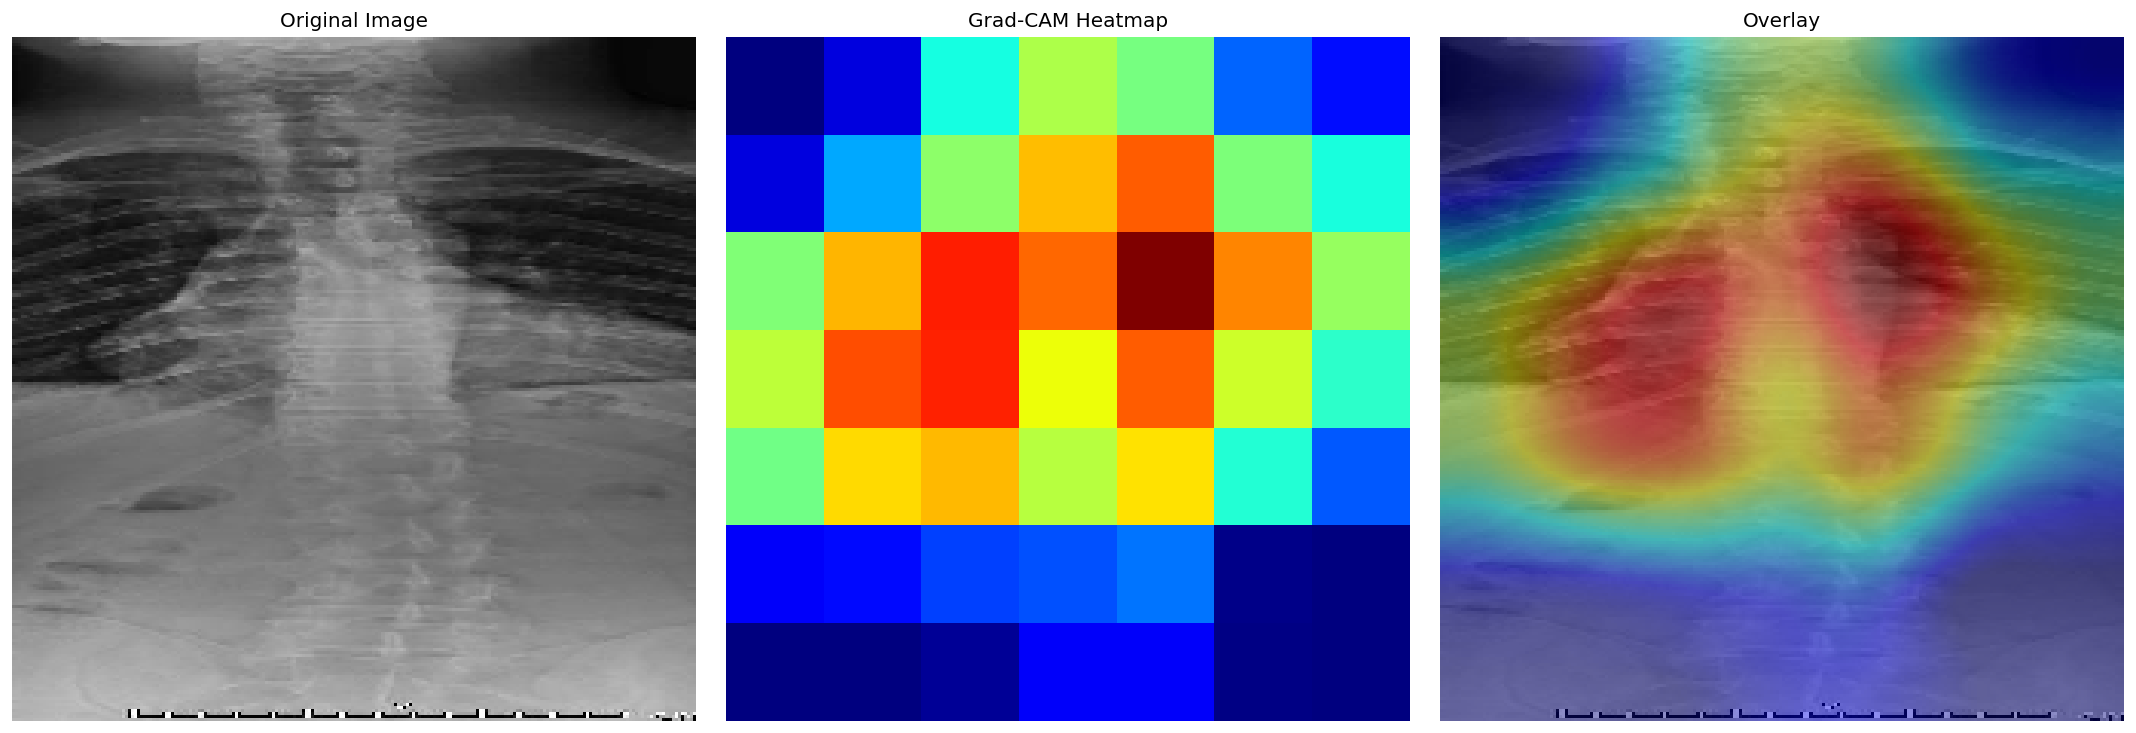

PREDICTION SUMMARY
File              : N1-N-40-M_1_0-Copy_jpg.rf.044ceccbb0b066aa81d2e055105083ea.jpg
True Class        : normal
Predicted Class   : normal
Confidence        : 0.9016
Prediction Status : Correct


In [35]:
# ==========================================================
# SINGLE IMAGE VISUALIZATION
# ==========================================================

print_section("Single Image Visualization")

sample = correct_predictions.iloc[0]

result = run_gradcam(
    sample["filepath"]
)

visualize_gradcam(result)

In [36]:
# ==========================================================
# MULTI SAMPLE VISUALIZATION
# ==========================================================

def visualize_group(
    dataframe,
    title,
    n=3
):

    print("\n")
    print("="*70)
    print(title)
    print("="*70)

    n = min(
        n,
        len(dataframe)
    )

    for i in range(n):

        sample = dataframe.iloc[i]

        result = run_gradcam(
            sample["filepath"]
        )

        print(
            f"\nSample {i+1}/{n}"
        )

        visualize_gradcam(result)



CORRECT NORMAL

Sample 1/3


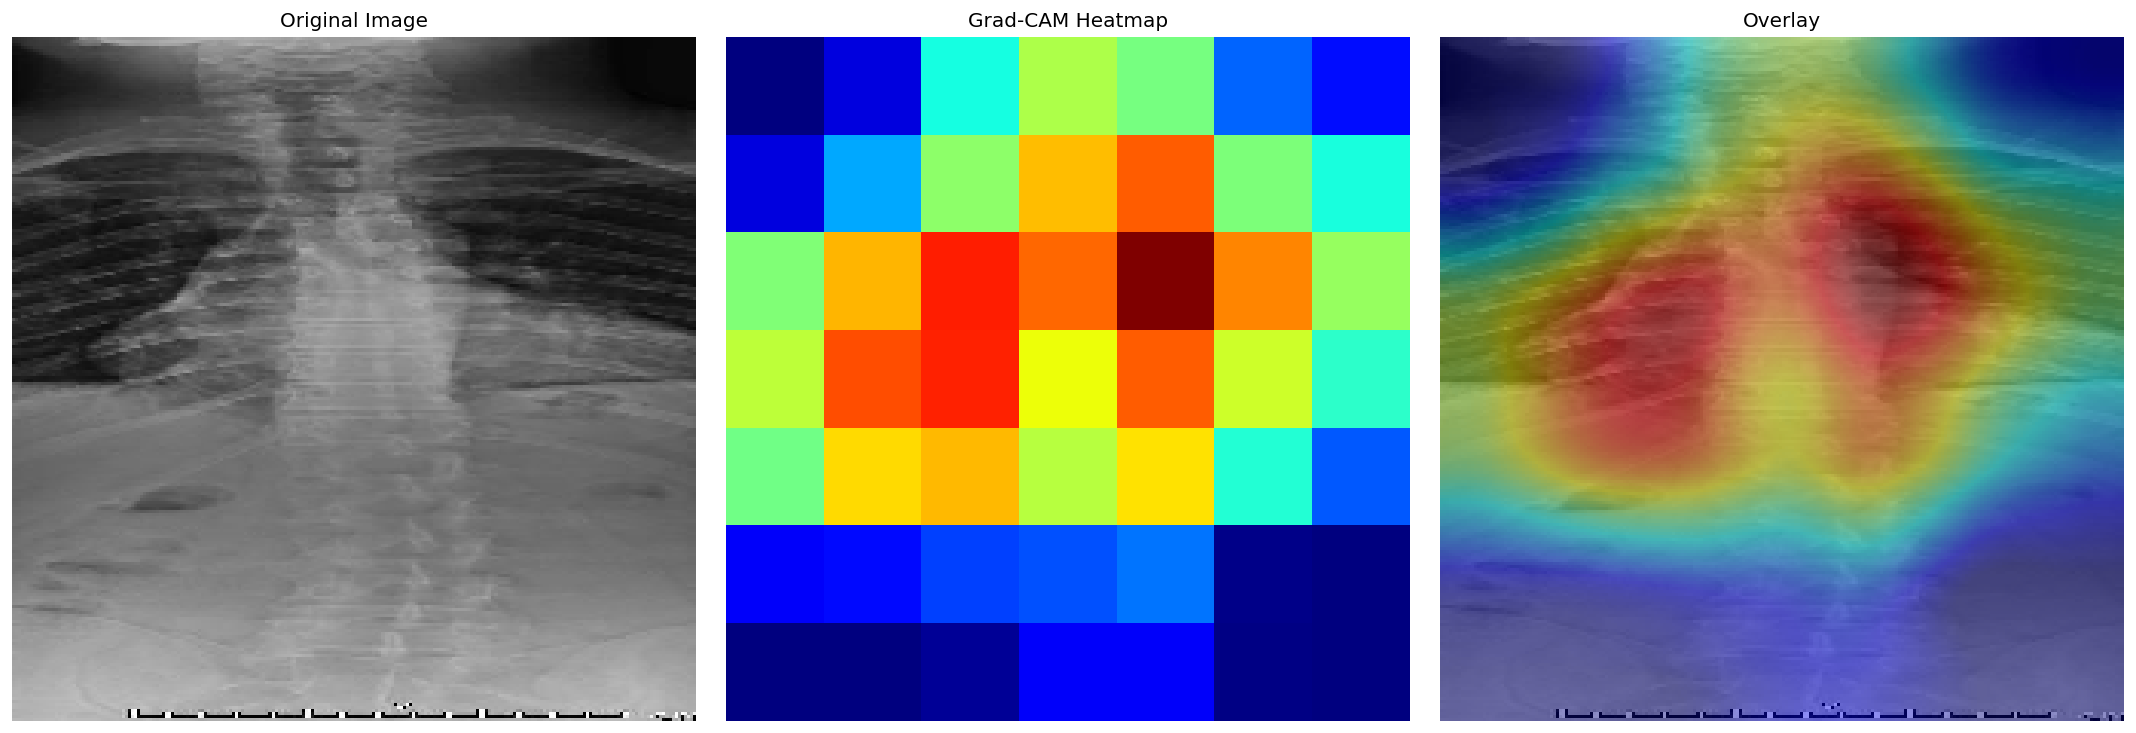

PREDICTION SUMMARY
File              : N1-N-40-M_1_0-Copy_jpg.rf.044ceccbb0b066aa81d2e055105083ea.jpg
True Class        : normal
Predicted Class   : normal
Confidence        : 0.9016
Prediction Status : Correct

Sample 2/3


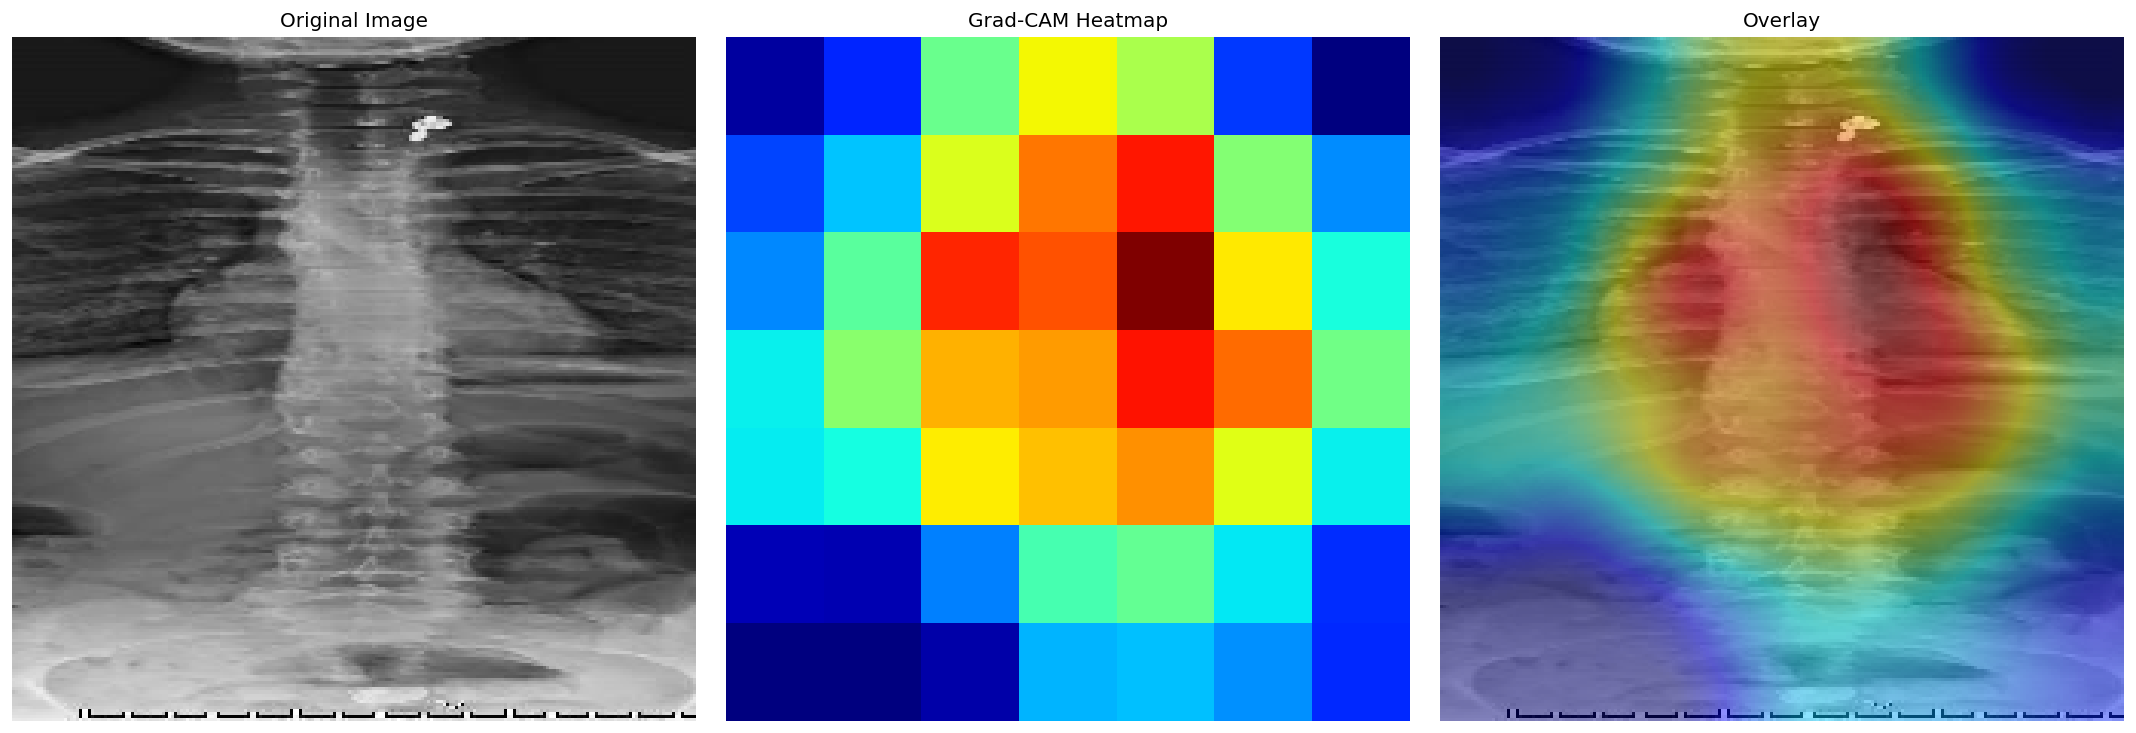

PREDICTION SUMMARY
File              : N13-N-F-15_1_0-Copy_jpg.rf.dd3dfddbca9179a263232b7c475d2eb4.jpg
True Class        : normal
Predicted Class   : normal
Confidence        : 0.9356
Prediction Status : Correct

Sample 3/3


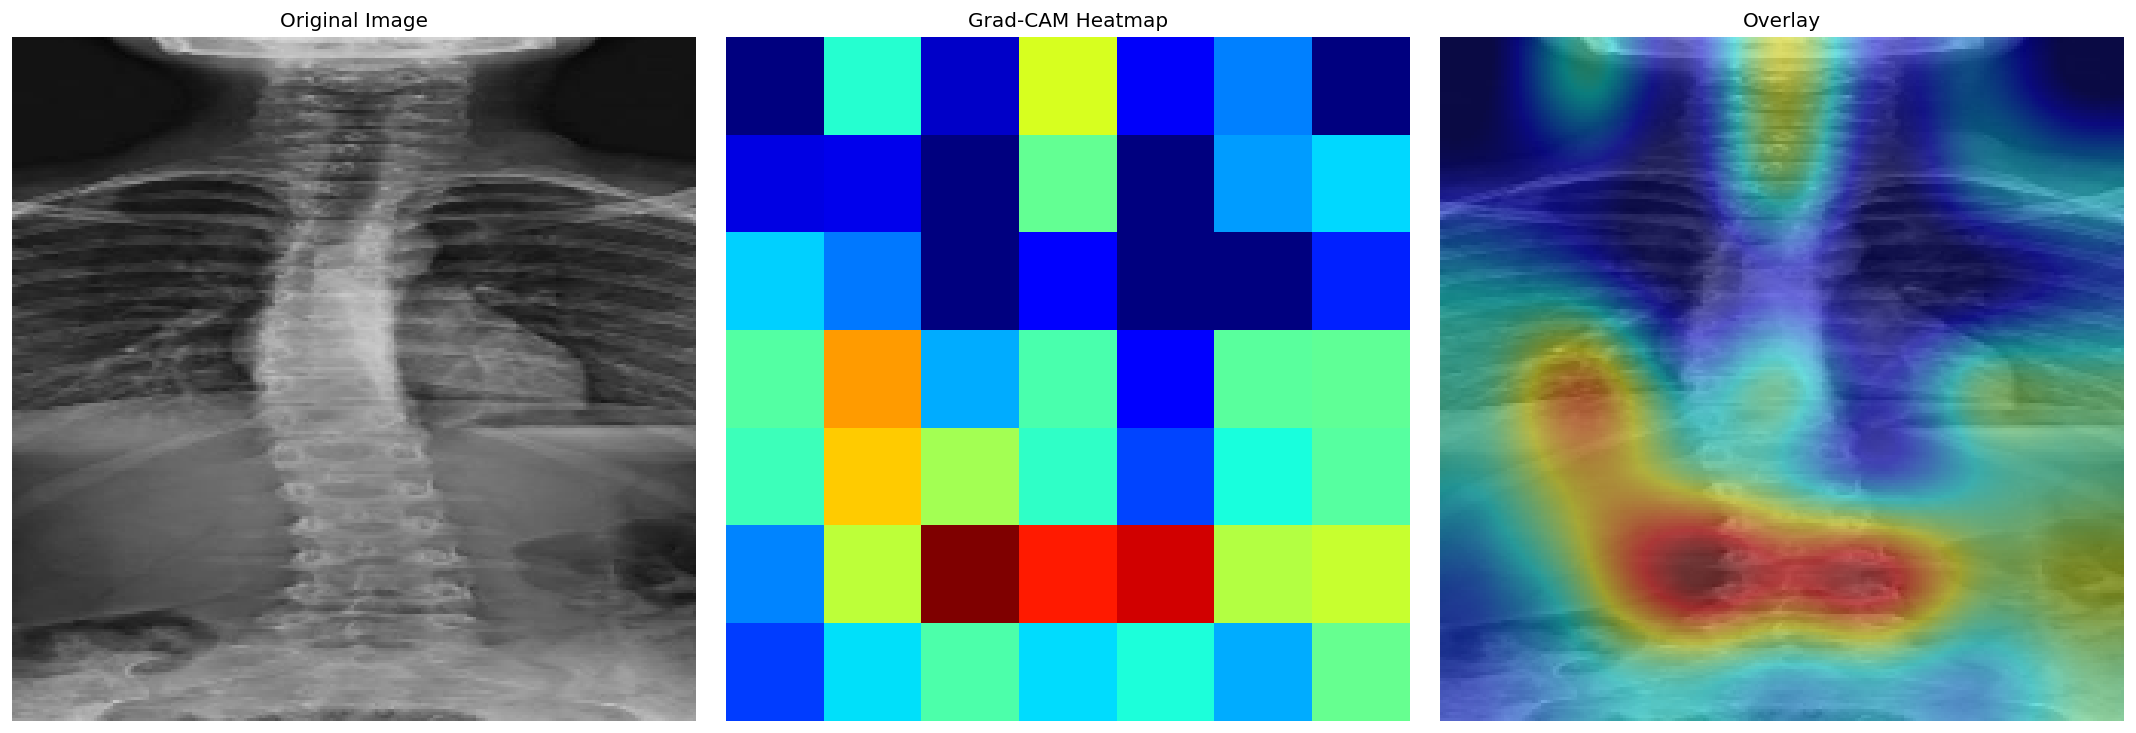

PREDICTION SUMMARY
File              : N18-N-F-13_1_0-Copy_jpg.rf.32f3a96d6c34ef1f581a32f710406ebd.jpg
True Class        : normal
Predicted Class   : normal
Confidence        : 0.6931
Prediction Status : Correct


CORRECT SCOLIOSIS

Sample 1/3


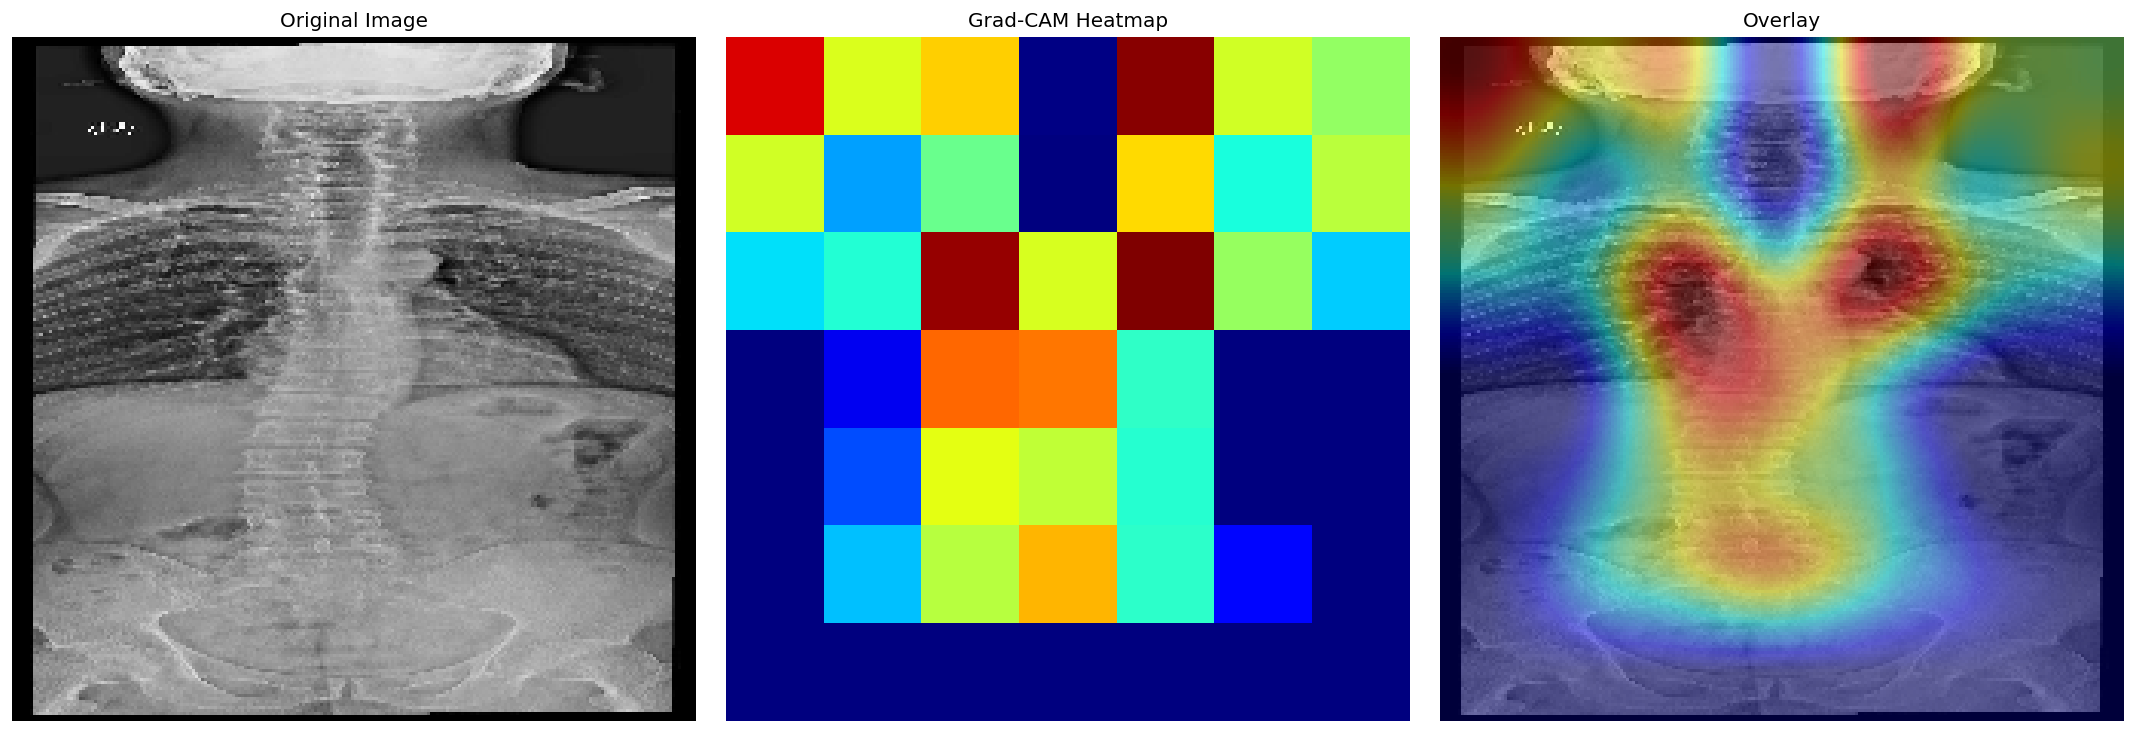

PREDICTION SUMMARY
File              : 01-July-2019-12_jpg.rf.7b50eaa213a8b18f7265593b0a27cd6f.jpg
True Class        : scoliosis
Predicted Class   : scoliosis
Confidence        : 0.7074
Prediction Status : Correct

Sample 2/3


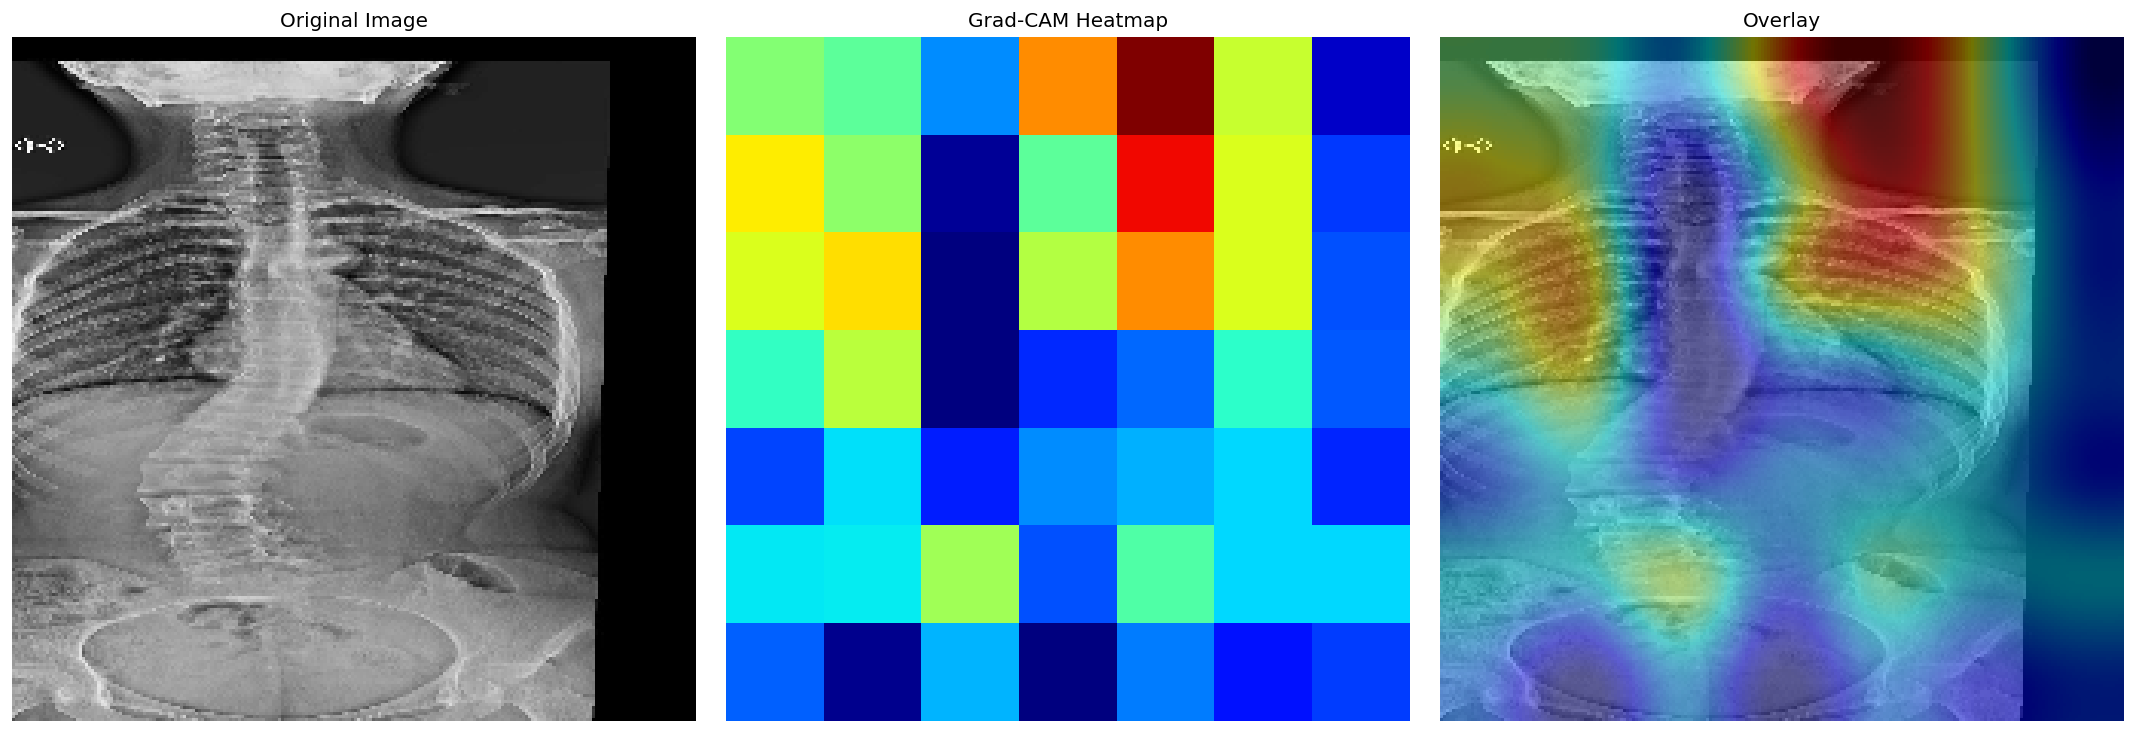

PREDICTION SUMMARY
File              : 01-July-2019-1_jpg.rf.a39bf99b90e14970b497076c97236a1a.jpg
True Class        : scoliosis
Predicted Class   : scoliosis
Confidence        : 0.8958
Prediction Status : Correct

Sample 3/3


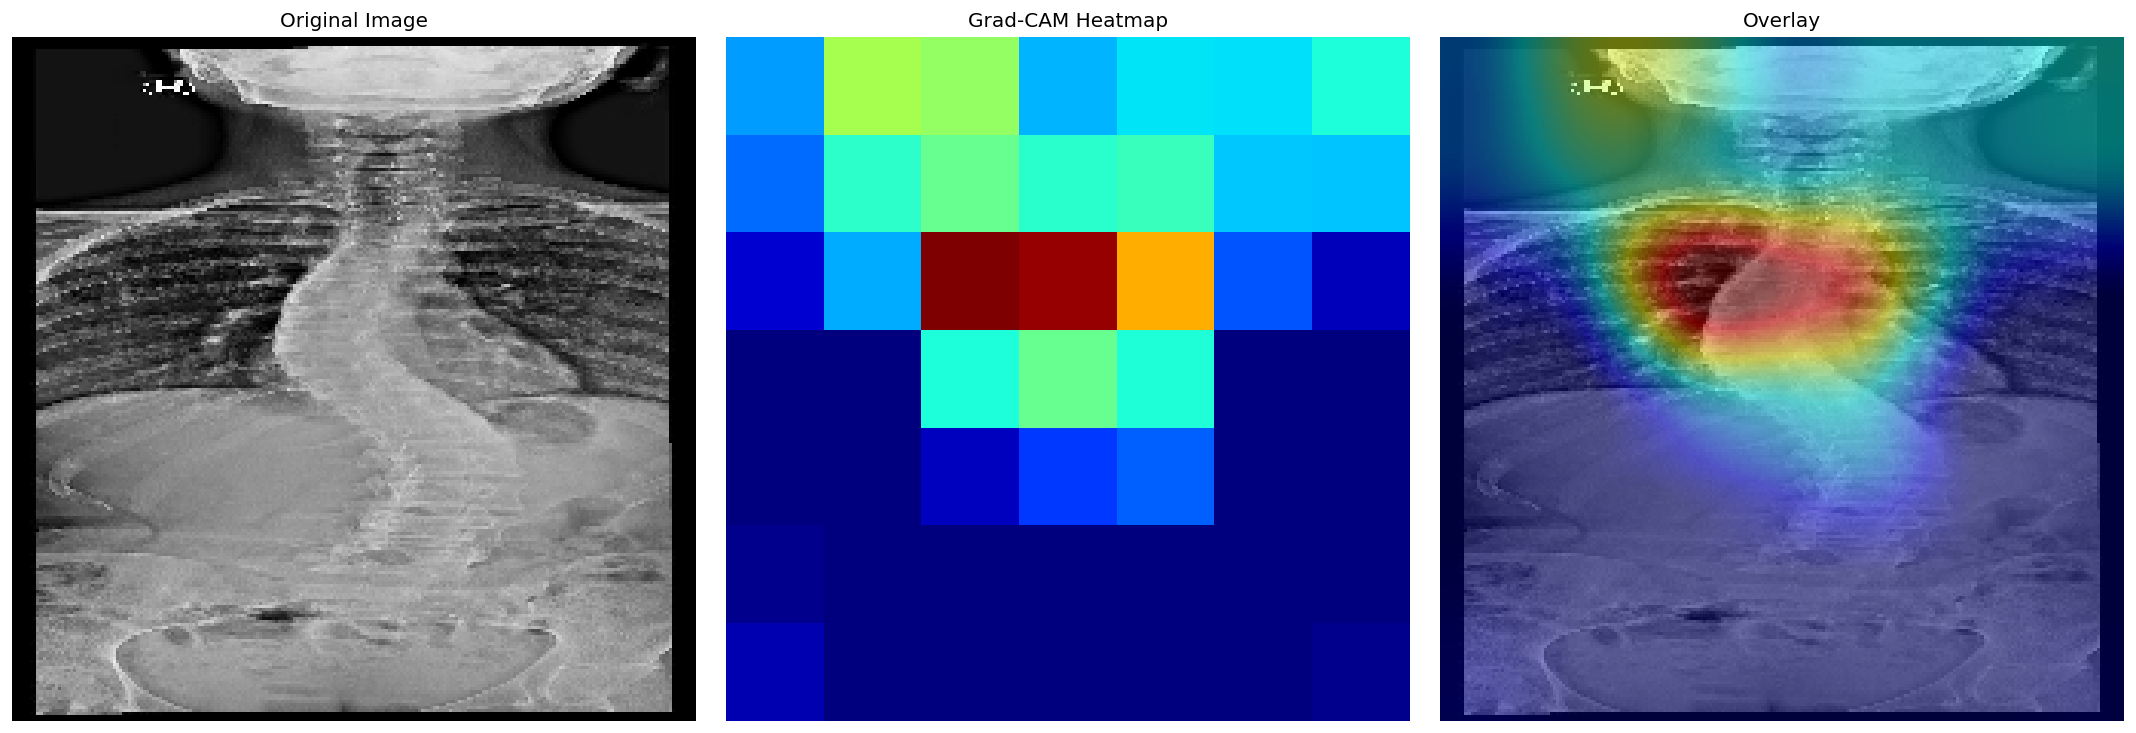

PREDICTION SUMMARY
File              : 01-July-2019-25_jpg.rf.833a16bafc1a99ac9cb58aa8bac099cb.jpg
True Class        : scoliosis
Predicted Class   : scoliosis
Confidence        : 0.7509
Prediction Status : Correct


WRONG NORMAL

Sample 1/2


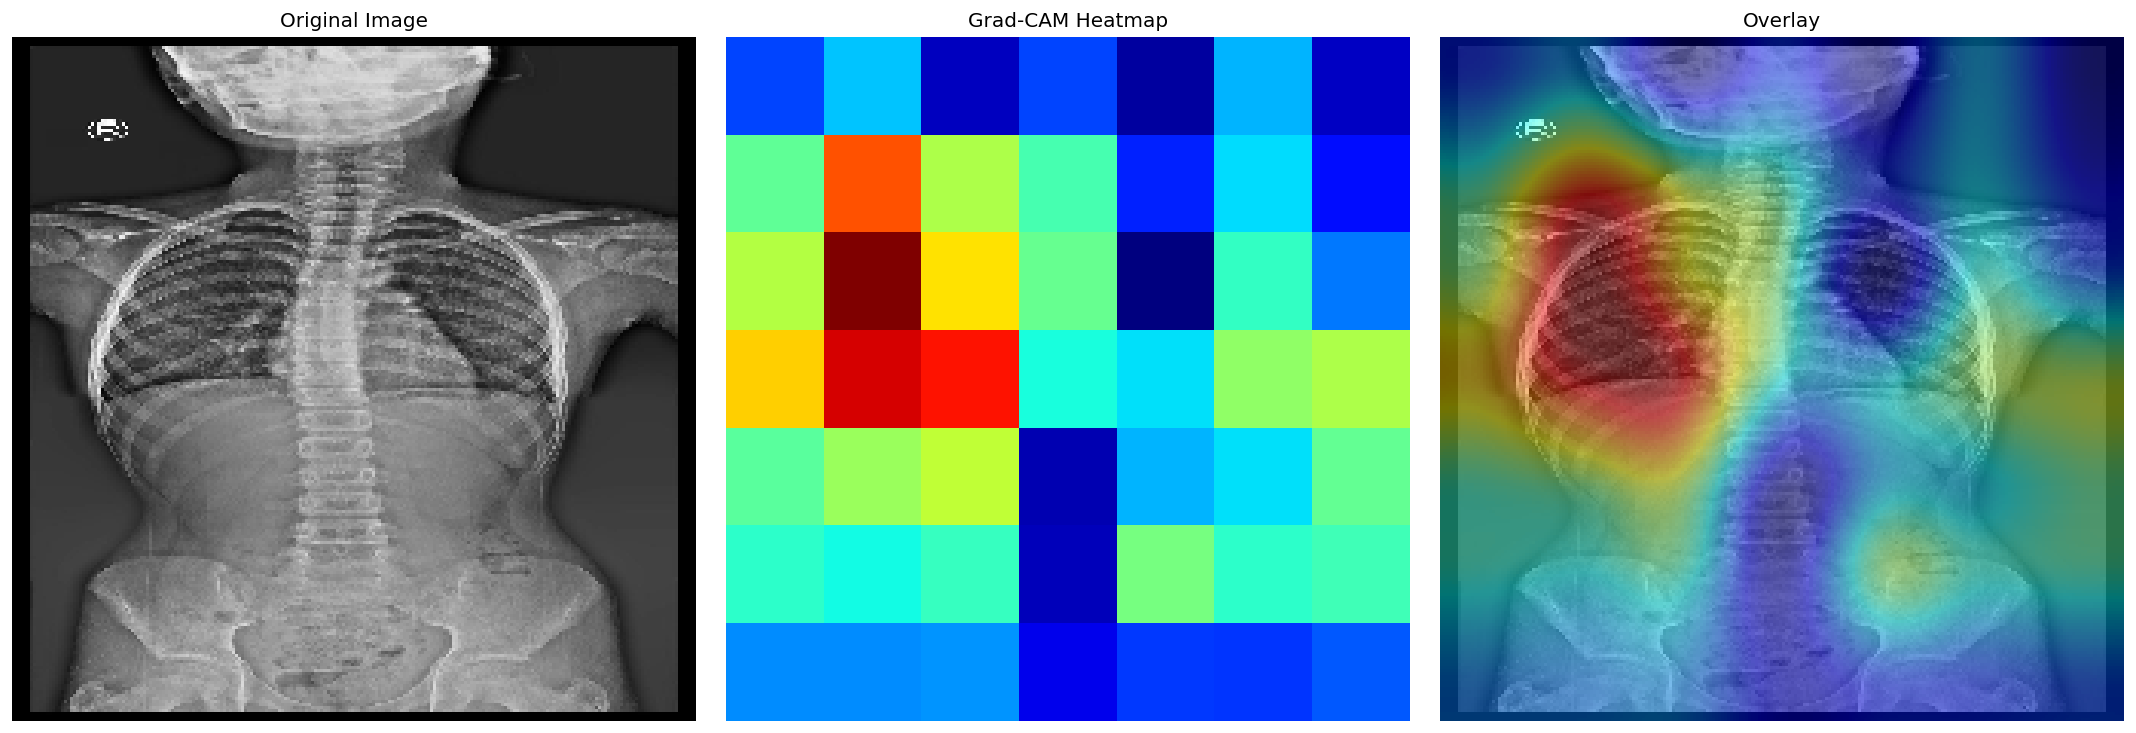

PREDICTION SUMMARY
File              : 01-July-2019-75_jpg.rf.553dd588aa79f1087b84519a42bdf05f.jpg
True Class        : normal
Predicted Class   : scoliosis
Confidence        : 0.8878
Prediction Status : Incorrect

Sample 2/2


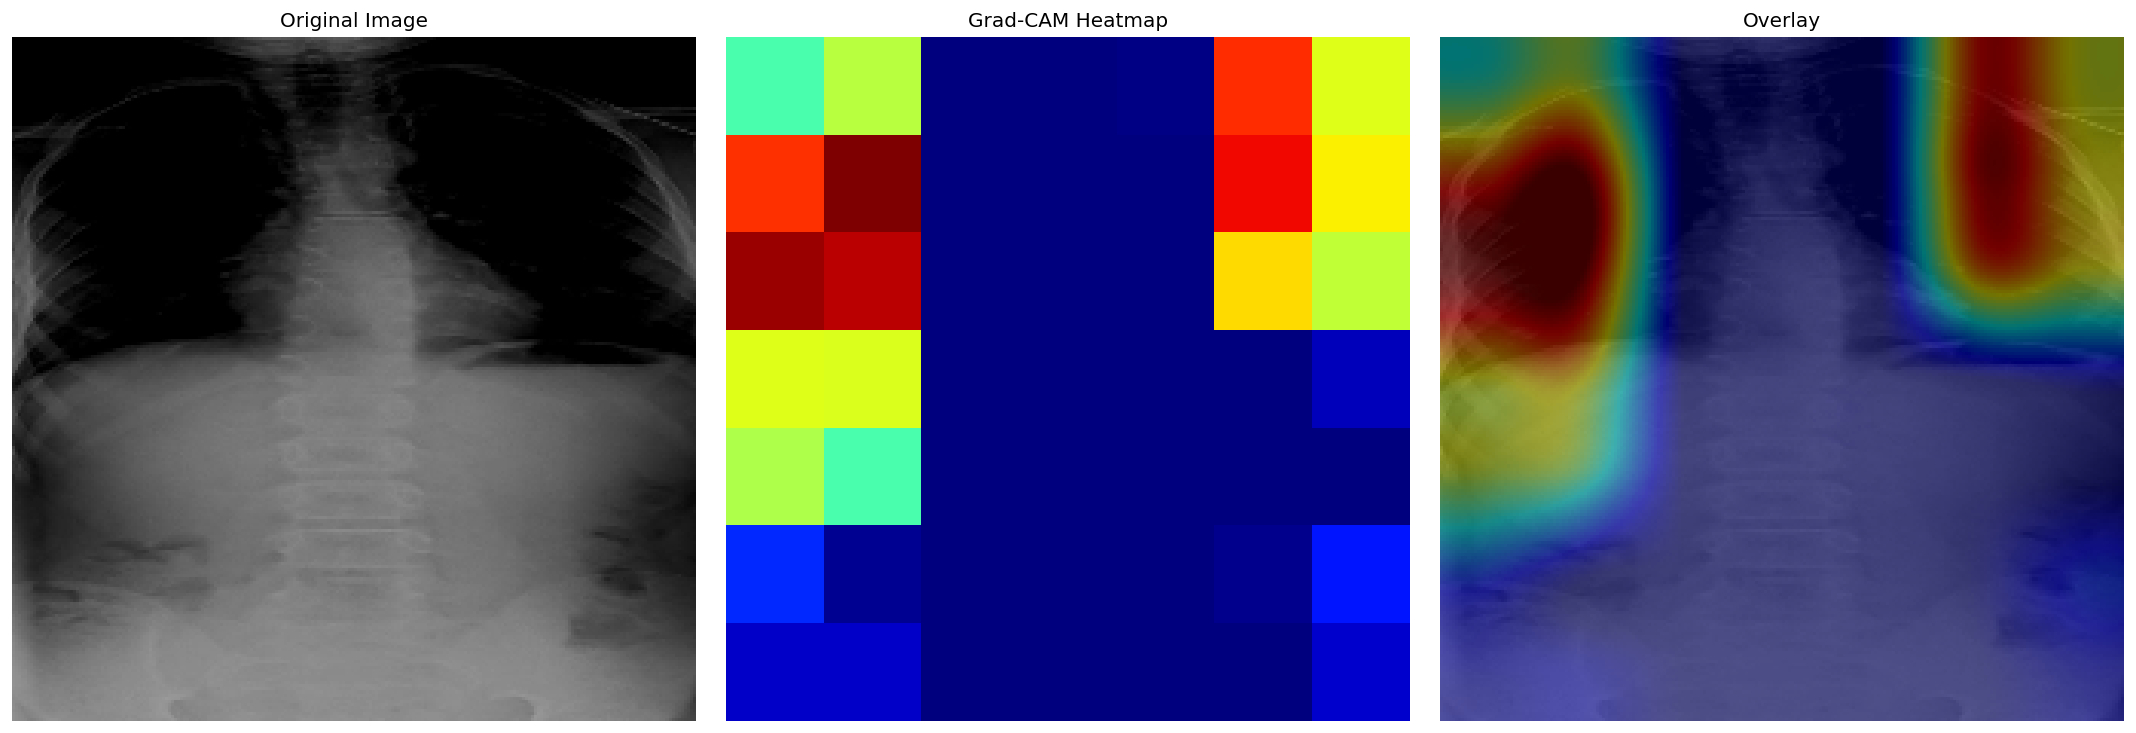

PREDICTION SUMMARY
File              : sunhl-1th-28-Feb-2017-294-B-AP_jpg.rf.87ab9d962b6651cf88353afab739b95f.jpg
True Class        : normal
Predicted Class   : scoliosis
Confidence        : 0.5434
Prediction Status : Incorrect


WRONG SCOLIOSIS

Sample 1/3


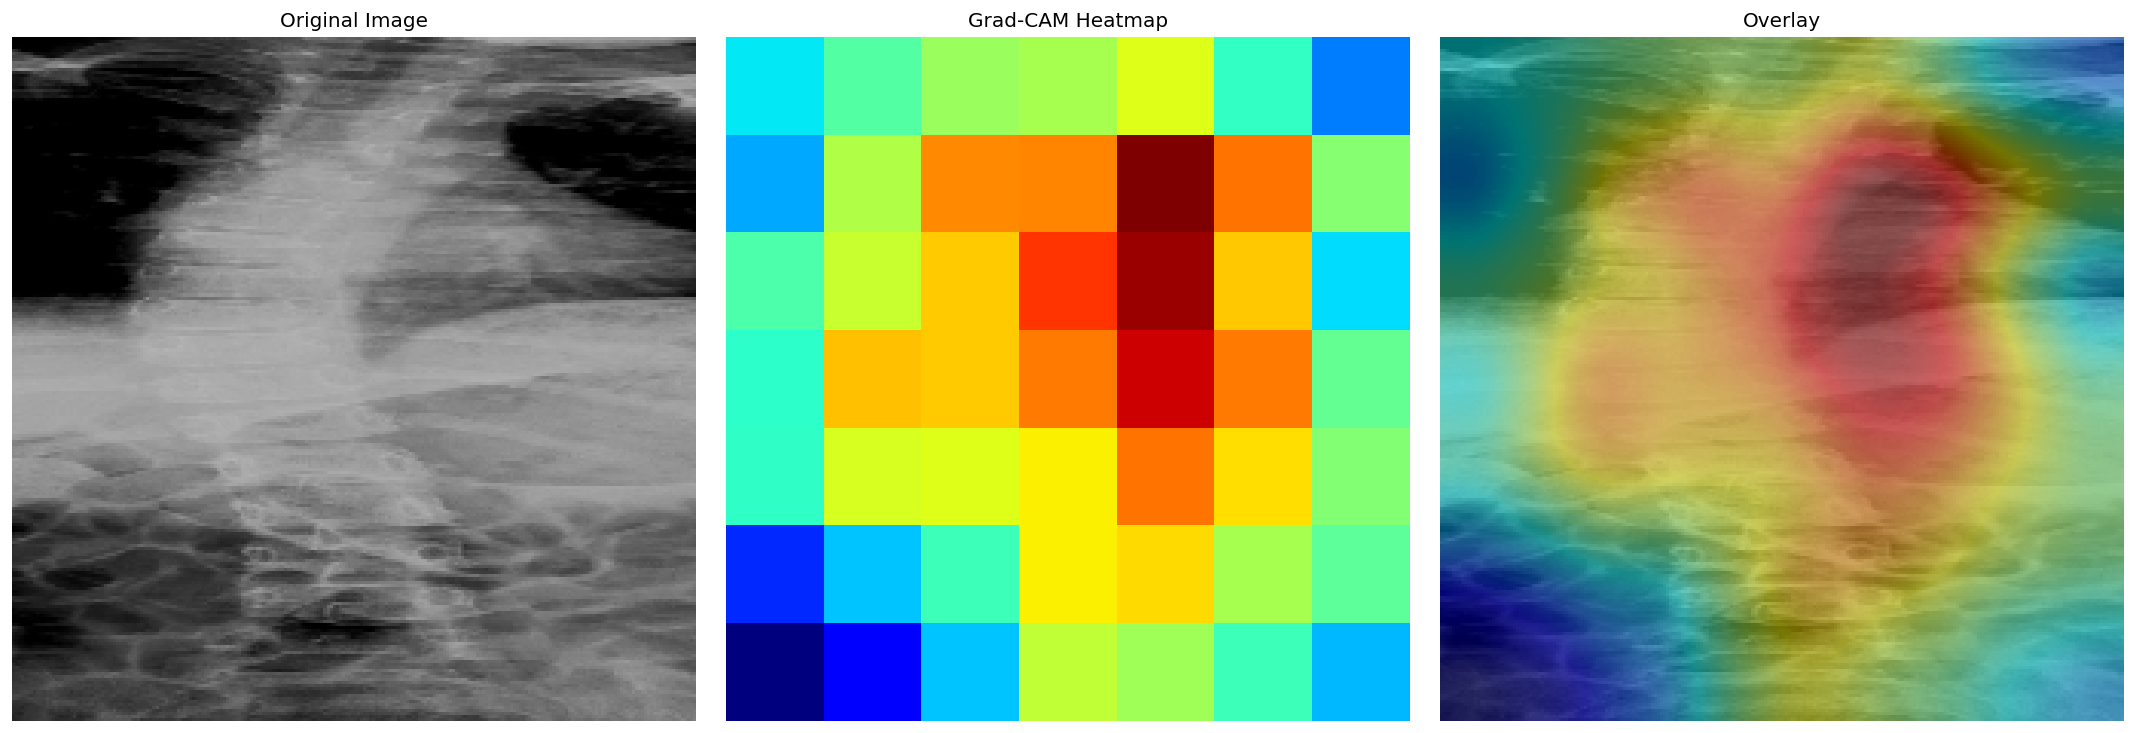

PREDICTION SUMMARY
File              : sunhl-1th-26-Jul-2016-76-B-AP_jpg.rf.ac0f4db16dc87f5a0ccc026b95ab6a8e.jpg
True Class        : scoliosis
Predicted Class   : normal
Confidence        : 0.9174
Prediction Status : Incorrect

Sample 2/3


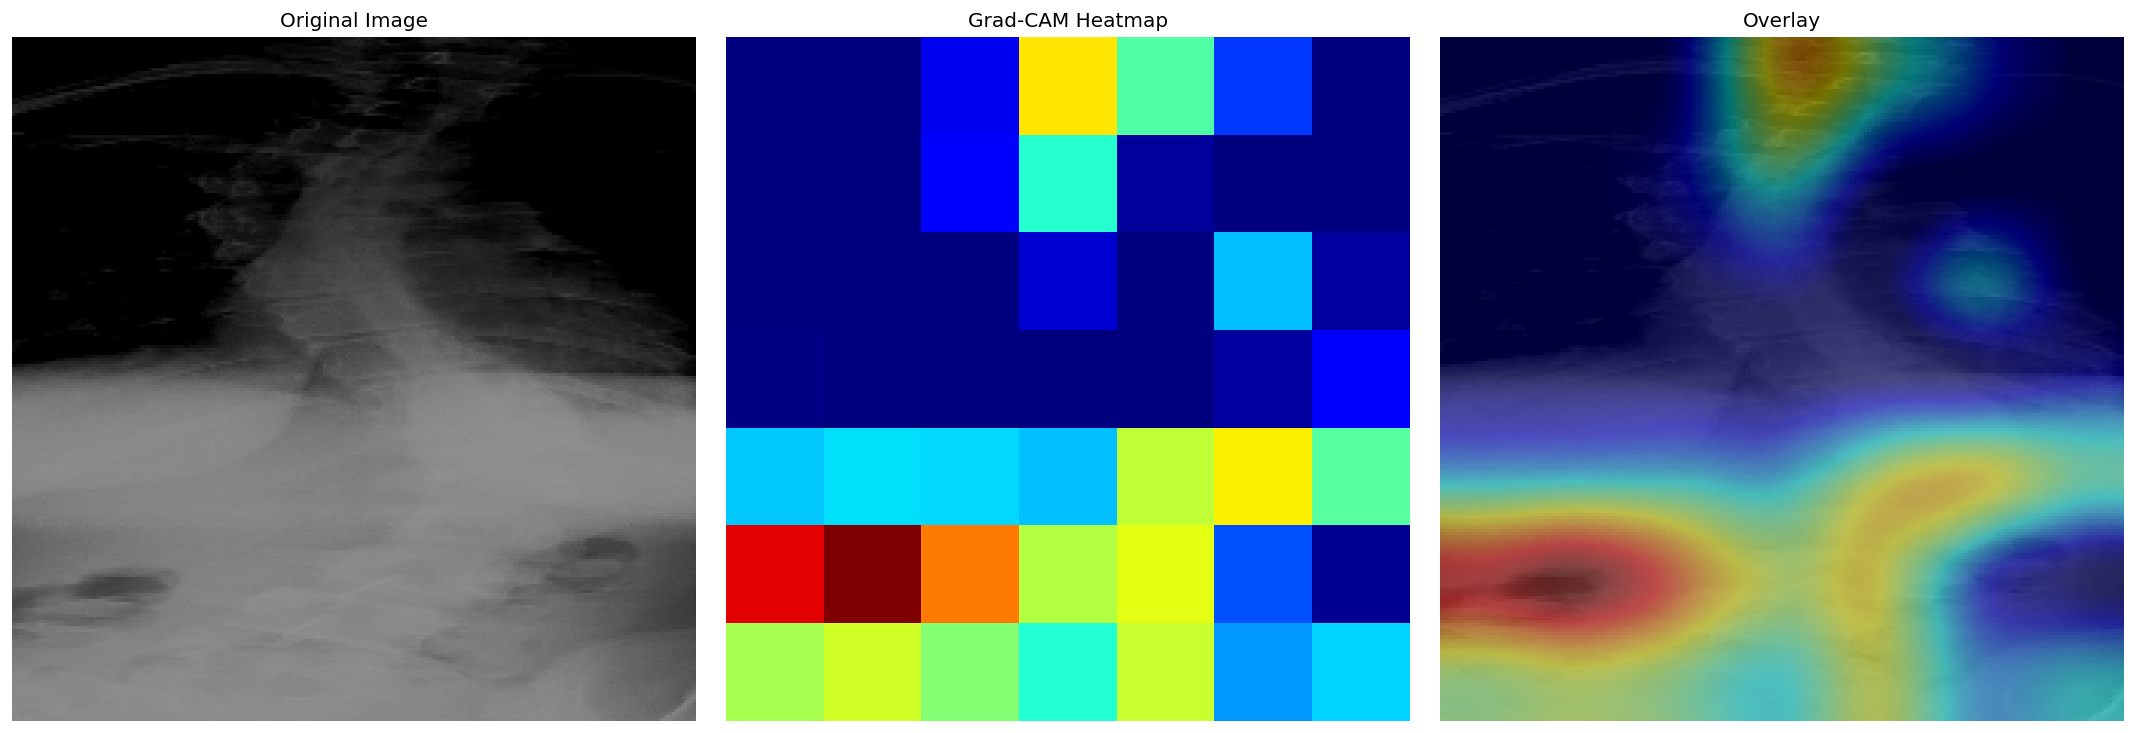

PREDICTION SUMMARY
File              : sunhl-1th-26-Jul-2016-77-C-AP_jpg.rf.59c23cf3cff287ee1c1014a585639f1b.jpg
True Class        : scoliosis
Predicted Class   : normal
Confidence        : 0.6597
Prediction Status : Incorrect

Sample 3/3


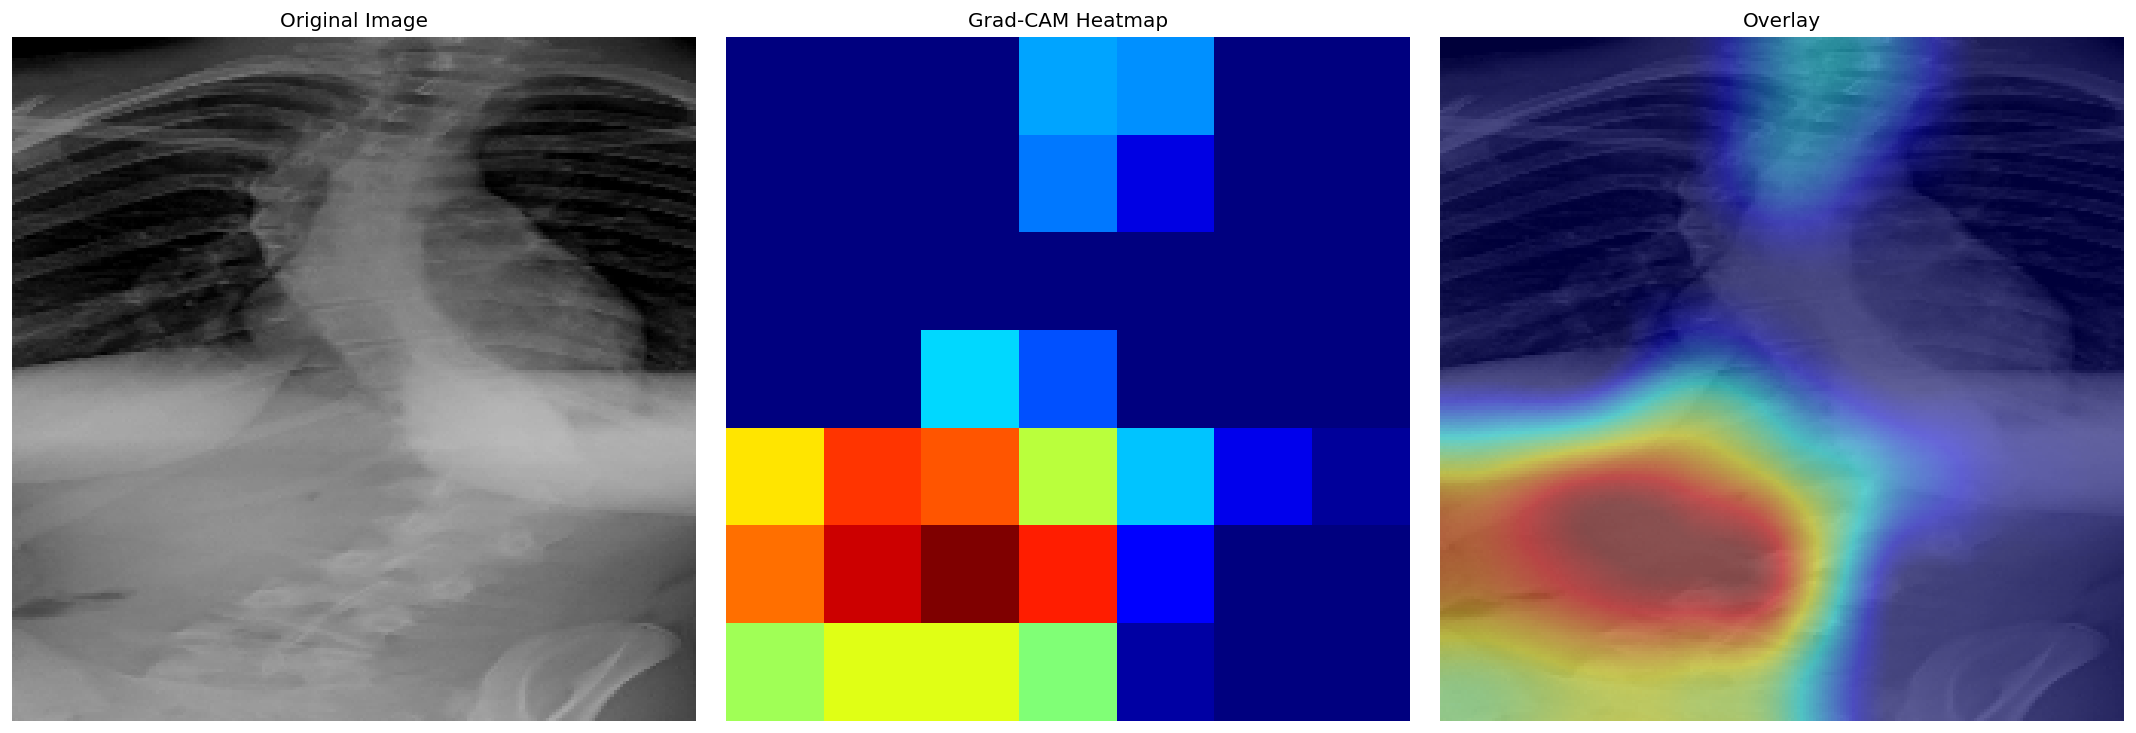

PREDICTION SUMMARY
File              : sunhl-1th-26-Jul-2016-77-D-AP_jpg.rf.f0952d8f331155edfc9579c6a0e97e27.jpg
True Class        : scoliosis
Predicted Class   : normal
Confidence        : 0.5418
Prediction Status : Incorrect


In [37]:
# ==========================================================
# VISUALIZE ALL GROUPS
# ==========================================================

visualize_group(

    correct_normal,

    "CORRECT NORMAL",

    n=3

)

visualize_group(

    correct_scoliosis,

    "CORRECT SCOLIOSIS",

    n=3

)

visualize_group(

    wrong_normal,

    "WRONG NORMAL",

    n=3

)

visualize_group(

    wrong_scoliosis,

    "WRONG SCOLIOSIS",

    n=3

)

# Automatic Heatmap Analysis

In [38]:
# ==========================================================
# CONFIDENCE LEVEL
# ==========================================================

def get_confidence_level(confidence):

    if confidence >= 0.90:

        return "High"

    elif confidence >= 0.70:

        return "Moderate"

    else:

        return "Low"

In [39]:
# ==========================================================
# HEATMAP STATISTICS
# ==========================================================

def compute_heatmap_statistics(
    heatmap
):

    threshold = CONFIG["minimum_threshold"]

    active = heatmap >= threshold

    coverage = np.mean(active) * 100

    max_activation = float(
        heatmap.max()
    )

    mean_activation = float(
        heatmap.mean()
    )

    ys, xs = np.where(active)

    if len(xs) == 0:

        center_x = None

        center_y = None

    else:

        center_x = float(xs.mean())

        center_y = float(ys.mean())

    return {

        "coverage": coverage,

        "maximum_activation": max_activation,

        "mean_activation": mean_activation,

        "center_x": center_x,

        "center_y": center_y

    }

In [40]:
# ==========================================================
# REGION ANALYSIS
# ==========================================================

def identify_region(stats):

    x = stats["center_x"]

    y = stats["center_y"]

    if x is None:

        return "No dominant activation"

    if x < 2:

        horizontal = "Left"

    elif x < 4:

        horizontal = "Center"

    else:

        horizontal = "Right"

    if y < 2:

        vertical = "Upper"

    elif y < 4:

        vertical = "Middle"

    else:

        vertical = "Lower"

    return f"{vertical}-{horizontal}"

In [41]:
# ==========================================================
# REGION DESCRIPTION
# ==========================================================

def region_to_text(region):

    mapping = {

        "Upper-Left": "upper-left thoracic region",

        "Upper-Center": "upper thoracic region",

        "Upper-Right": "upper-right thoracic region",

        "Middle-Left": "left thoracic region",

        "Middle-Center": "central thoracic region",

        "Middle-Right": "right thoracic region",

        "Lower-Left": "left lower thoracic region",

        "Lower-Center": "lower thoracic region",

        "Lower-Right": "right lower thoracic region"

    }

    return mapping.get(region, region)

In [42]:
# ==========================================================
# AUTOMATIC INTERPRETATION
# ==========================================================

def interpret_heatmap(result, stats, region):

    region_text = region_to_text(region)

    technical = []

    clinical = []

    # ======================================================
    # TECHNICAL INTERPRETATION
    # ======================================================

    if stats["coverage"] < 20:

        technical.append(
            "Activation is highly localized."
        )

    elif stats["coverage"] < 40:

        technical.append(
            "Activation is moderately distributed."
        )

    else:

        technical.append(
            "Activation is broadly distributed."
        )

    technical.append(
        f"Dominant activation is located in the {region_text}."
    )

    if stats["mean_activation"] >= 0.45:

        technical.append(
            "High average activation intensity."
        )

    else:

        technical.append(
            "Moderate average activation intensity."
        )

    if stats["maximum_activation"] >= 0.90:

        technical.append(
            "Strong activation peak detected."
        )

    # ======================================================
    # CLINICAL INTERPRETATION
    # ======================================================

    if result["is_correct"]:

        clinical.append(
            "The prediction is consistent with the ground truth."
        )

    else:

        clinical.append(
            "The prediction differs from the ground truth."
        )

    if stats["coverage"] >= 45:

        clinical.append(
            "The model appears to utilize multiple anatomical structures rather than relying on a single localized feature."
        )

    else:

        clinical.append(
            "The model appears to focus on a relatively localized anatomical region."
        )

    clinical.append(

        f"The primary attention is concentrated around the {region_text}, which contains important anatomical information for spinal alignment assessment."

    )

    if result["is_correct"]:

        clinical.append(

            "Because the prediction is correct, the highlighted regions are likely to contain image features that contributed positively to the model's decision."

        )

    else:

        clinical.append(

            "Because the prediction is incorrect, the highlighted regions may indicate that the model relied on contextual features that contributed to the misclassification."

        )

    return technical, clinical

In [43]:
# ==========================================================
# ANALYSIS ENGINE
# ==========================================================

def analyze_gradcam(result):

    # ------------------------------------------------------
    # Heatmap Statistics
    # ------------------------------------------------------

    stats = compute_heatmap_statistics(
        result["heatmap"]
    )

    # ------------------------------------------------------
    # Region Analysis
    # ------------------------------------------------------

    region = identify_region(
        stats
    )

    # ------------------------------------------------------
    # Automatic Interpretation
    # ------------------------------------------------------

    technical, clinical = interpret_heatmap(
        result,
        stats,
        region
    )

    # ------------------------------------------------------
    # Analysis Object
    # ------------------------------------------------------

    analysis = {

        **stats,

        "dominant_region": region,

        "technical": technical,

        "clinical": clinical

    }

    return analysis

In [44]:
# ==========================================================
# REPORT GENERATOR
# ==========================================================

from datetime import datetime

def print_gradcam_report(result, analysis):

    confidence_pct = result["confidence"] * 100

    confidence_level = get_confidence_level(
        result["confidence"]
    )

    timestamp = datetime.now().strftime(
        "%Y-%m-%d %H:%M:%S"
    )

    print("=" * 70)
    print("GRAD-CAM REPORT")
    print("=" * 70)

    print(f"Generated         : {timestamp}")

    print(f"Model             : {MODEL_INFO['model_name']}")

    print(f"Experiment        : {MODEL_INFO['experiment']}")

    print(f"Image             : {os.path.basename(result['filepath'])}")

    print()

    print("Prediction")
    print("-" * 25)

    print(f"True Class        : {result['true_class']}")

    print(f"Predicted Class   : {result['predicted_class']}")

    print(f"Confidence        : {confidence_pct:.2f}%")

    print(f"Confidence Level  : {confidence_level}")

    print(f"Prediction Status : {result['prediction_status']}")

    print()

    print("Heatmap Statistics")
    print("-" * 25)

    print(f"Activation Coverage : {analysis['coverage']:.2f}%")

    print(f"Maximum Activation  : {analysis['maximum_activation']:.4f}")

    print(f"Mean Activation     : {analysis['mean_activation']:.4f}")

    print(f"Dominant Region     : {region_to_text(analysis['dominant_region']).title()}")

    print()

    print("Technical Interpretation")
    print("-" * 25)

    for sentence in analysis["technical"]:

        print(f"• {sentence}")

    print()

    print("Clinical Interpretation")
    print("-" * 25)

    for sentence in analysis["clinical"]:

        print(f"• {sentence}")

    print()

    print("=" * 70)

In [45]:
#Demo
sample = run_gradcam(
    correct_scoliosis.iloc[0]["filepath"]
)

analysis = analyze_gradcam(sample)

print_gradcam_report(
    sample,
    analysis
)

GRAD-CAM REPORT
Generated         : 2026-06-26 07:10:10
Model             : DenseNet121
Experiment        : E4
Image             : 01-July-2019-12_jpg.rf.7b50eaa213a8b18f7265593b0a27cd6f.jpg

Prediction
-------------------------
True Class        : scoliosis
Predicted Class   : scoliosis
Confidence        : 70.74%
Confidence Level  : Moderate
Prediction Status : Correct

Heatmap Statistics
-------------------------
Activation Coverage : 51.02%
Maximum Activation  : 1.0000
Mean Activation     : 0.3588
Dominant Region     : Central Thoracic Region

Technical Interpretation
-------------------------
• Activation is broadly distributed.
• Dominant activation is located in the central thoracic region.
• Moderate average activation intensity.
• Strong activation peak detected.

Clinical Interpretation
-------------------------
• The prediction is consistent with the ground truth.
• The model appears to utilize multiple anatomical structures rather than relying on a single localized feature.


In [46]:
print_section("Analysis Validation")

analysis = analyze_gradcam(
    run_gradcam(
        prediction_df.iloc[0]["filepath"]
    )
)

checks = {

    "Coverage":
        "coverage" in analysis,

    "Maximum Activation":
        "maximum_activation" in analysis,

    "Mean Activation":
        "mean_activation" in analysis,

    "Dominant Region":
        "dominant_region" in analysis,

    "Technical Interpretation":
        len(analysis["technical"]) > 0,

    "Clinical Interpretation":
        len(analysis["clinical"]) > 0

}

ready = True

for name, status in checks.items():

    print_status(name, status)

    ready &= status

print()

if ready:

    print("="*70)
    print("SECTION 6 STATUS : READY")
    print("="*70)

else:

    print("="*70)
    print("SECTION 6 STATUS : FAILED")
    print("="*70)


ANALYSIS VALIDATION
Coverage                           : PASS
Maximum Activation                 : PASS
Mean Activation                    : PASS
Dominant Region                    : PASS
Technical Interpretation           : PASS
Clinical Interpretation            : PASS

SECTION 6 STATUS : READY


# Export Engine

In [47]:
# ==========================================================
# ENGINE CONTEXT
# ==========================================================

ENGINE_CONTEXT = {

    "model": best_model,

    "config": CONFIG,

    "model_info": MODEL_INFO,

    "last_conv_layer": LAST_CONV_LAYER

}

print_section("Engine Context")

for key in ENGINE_CONTEXT:

    print(f"{key:<20}: READY")

print()

print("="*70)
print("ENGINE CONTEXT : READY")
print("="*70)


ENGINE CONTEXT
model               : READY
config              : READY
model_info          : READY
last_conv_layer     : READY

ENGINE CONTEXT : READY


In [48]:
# ==========================================================
# ENGINE MANIFEST
# ==========================================================

print_section("Engine Manifest")

ENGINE_MANIFEST = {

    # ------------------------------------------------------
    # Core Explainable AI Functions
    # ------------------------------------------------------

    "core_functions": [

        "predict_image",

        "run_gradcam",

        "analyze_gradcam",

        "generate_report"

    ],

    # ------------------------------------------------------
    # Internal Helper Functions
    # ------------------------------------------------------

    "internal_functions": [

        "load_image",

        "preprocess_image",

        "generate_heatmap",

        "generate_overlay",

        "compute_heatmap_statistics",

        "identify_region",

        "region_to_text",

        "get_confidence_level",

        "interpret_heatmap"

    ],

    # ------------------------------------------------------
    # Notebook Information
    # ------------------------------------------------------

    "description":

        "Reusable Explainable AI components for deployment.",

    "target":

        "Notebook 4"

}

print("Core Functions")

for func in ENGINE_MANIFEST["core_functions"]:

    print(f"  • {func}")

print()

print("Internal Functions")

for func in ENGINE_MANIFEST["internal_functions"]:

    print(f"  • {func}")

print()

print("Deployment Target")

print(f"  • {ENGINE_MANIFEST['target']}")

print()

print("=" * 70)
print("ENGINE MANIFEST : READY")
print("=" * 70)


ENGINE MANIFEST
Core Functions
  • predict_image
  • run_gradcam
  • analyze_gradcam
  • generate_report

Internal Functions
  • load_image
  • preprocess_image
  • generate_heatmap
  • generate_overlay
  • compute_heatmap_statistics
  • identify_region
  • region_to_text
  • get_confidence_level
  • interpret_heatmap

Deployment Target
  • Notebook 4

ENGINE MANIFEST : READY
